# Analysis of Utilized Model Capacity (Local Effective Dimension)

This notebook implements the Local Effective Dimension (LED) of Abbas et al. (2021, [arXiv:2011.00027](https://arxiv.org/abs/2011.00027)) for the trained weights of the VQC models in this project.

LED estimates the number of parameter directions that the converged solution $\theta^*$ actually exploits, **locally** at $\theta^*$. We follow the paper's definition (Eq. 4) and use Qiskit's lower-level primitives so that we can regularize the empirical Fisher and report uncertainty across folds.

**Goal:** compare local capacity for different ansatz depths (2, 4, 6) and environments (Odra / Simulator) using the same per-fold splits the models were trained on.

### Methodology (matched to the paper and to the per-fold training setup)

* For every weight file `fold_F/...epoch_30_weights.pth` we load **fold F's own training CSV** (`cross_validation/Data/fold_F/train_data.csv`) and:
  * draw `k = 200` input samples from that CSV (no leakage from the held-out partition) to estimate the empirical Fisher $\hat{F}(\theta^*)$ via Monte Carlo,
  * use **`n` = number of training points actually seen by that fold** (1097 or 1098) as the dataset size in the LED formula,
  * normalize the empirical Fisher to have trace `d` (Abbas et al., §3) and add a small ridge $\hat{F}\leftarrow\hat{F}+\varepsilon I$ with $\varepsilon = 10^{-8}$ to stabilize `slogdet` for rank-deficient folds,
  * compute LED at $\gamma = 1$ as $d_{\gamma,n}=\log\det(I+\kappa\hat F)\,/\,\log\kappa$ with $\kappa = \gamma n / (2\pi\log n)$.
* Reported numbers are **mean ± std across the 5 folds** per (environment, depth).

### Scope of the noise comparison

Both `*_epoch_30_weights.pth` and `*_noise_epoch_30_weights.pth` files are loaded, but the Fisher Information Matrix is always computed with a noise-free `StatevectorEstimator`. The "Noise" column therefore distinguishes **where the trained weights came from** (training run executed under a noise model vs. ideal training), not the channel used to evaluate LED. The reported LED is thus *"how much local capacity these weights express in an ideal model"*, which isolates the effect of noise on the converged solution from the effect of noise on the live model.

In [1]:
import os
import glob
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.primitives import StatevectorEstimator
from qiskit.quantum_info import SparsePauliOp
from qiskit_machine_learning.connectors import TorchConnector
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.neural_networks import LocalEffectiveDimension
from qiskit_algorithms.gradients import ParamShiftEstimatorGradient

np.random.seed(42)
torch.manual_seed(42)

In [2]:
def ansatz_trimmed_reverse_q0_param_count(n_qubits: int, depth: int) -> int:
    m = depth // 2
    if m == 0:
        return 0
    full = 4 * n_qubits
    last = 3 * n_qubits + 2
    return (m - 1) * full + last

def odra_ansatz(n_qubits: int, depth: int) -> QuantumCircuit:
    n_macro = depth // 2
    theta = ParameterVector("theta", ansatz_trimmed_reverse_q0_param_count(n_qubits, depth))
    qc = QuantumCircuit(n_qubits)
    p = 0

    for j in range(n_macro):
        last_layer = j == n_macro - 1
        for i in range(n_qubits):
            qc.ry(theta[p + i], i)
        p += n_qubits
        for i in range(n_qubits):
            control = i
            target = (i + 1) % n_qubits
            qc.rz(theta[p + i], target)
            qc.cz(control, target)
        p += n_qubits
        for i in range(n_qubits):
            qc.rx(theta[p + i], i)
        p += n_qubits
        if last_layer:
            for k in range(2):
                i = k
                control = i
                target = (i - 1) % n_qubits
                qc.ry(theta[p + k], target)
                qc.cz(control, target)
            p += 2
        else:
            for i in range(n_qubits):
                control = i
                target = (i - 1) % n_qubits
                qc.ry(theta[p + i], target)
                qc.cz(control, target)
            p += n_qubits
    return qc

def simulator_ansatz(n_qubits: int, depth: int) -> QuantumCircuit:
    n_macro = depth // 2
    theta = ParameterVector("theta", ansatz_trimmed_reverse_q0_param_count(n_qubits, depth))
    qc = QuantumCircuit(n_qubits)
    param_idx = 0

    for j in range(n_macro):
        last_layer = j == n_macro - 1
        for i in range(n_qubits):
            qc.ry(theta[param_idx], i)
            param_idx += 1
        for i in range(n_qubits):
            control = i
            target = (i + 1) % n_qubits
            qc.crx(theta[param_idx], control, target)
            param_idx += 1
        for i in range(n_qubits):
            qc.rx(theta[param_idx], i)
            param_idx += 1
        if last_layer:
            for k in range(2):
                i = k
                control = i
                target = (i - 1) % n_qubits
                qc.cry(theta[param_idx], control, target)
                param_idx += 1
        else:
            for i in range(n_qubits):
                control = i
                target = (i - 1) % n_qubits
                qc.cry(theta[param_idx], control, target)
                param_idx += 1
    return qc

class HybridModel(nn.Module):
    def __init__(self, ansatz_circuit, num_qubits):
        super().__init__()
        self.feature_map = self._create_angle_encoding(num_qubits)
        self.qc = QuantumCircuit(num_qubits)
        self.qc.compose(self.feature_map, qubits=range(num_qubits), inplace=True)
        self.qc.compose(ansatz_circuit, inplace=True)

        input_params = list(self.feature_map.parameters)
        weight_params = list(ansatz_circuit.parameters)
        observable = SparsePauliOp.from_list([("I" * (num_qubits - 1) + "Z", 1)])
        
        estimator = StatevectorEstimator()
        gradient = ParamShiftEstimatorGradient(estimator)

        self.qnn = EstimatorQNN(
            circuit=self.qc,
            observables=observable,
            input_params=input_params,
            weight_params=weight_params,
            estimator=estimator,
            gradient=gradient
        )
        self.quantum_layer = TorchConnector(self.qnn)

    def _create_angle_encoding(self, num_qubits: int) -> QuantumCircuit:
        qc_data = QuantumCircuit(num_qubits)
        input_params = ParameterVector('x', num_qubits)
        for i in range(num_qubits):
            qc_data.ry(input_params[i], i)
        return qc_data

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.quantum_layer(x)

In [3]:
an_odra = odra_ansatz(5, 2)
print(an_odra)

     ┌──────────────┐                   ┌──────────────┐                 »
q_0: ┤ Ry(theta[0]) ├─────────────────■─┤ Rz(theta[9]) ├─────────────────»
     ├──────────────┤┌──────────────┐ │ └──────────────┘┌───────────────┐»
q_1: ┤ Ry(theta[1]) ├┤ Rz(theta[5]) ├─■────────■────────┤ Rx(theta[11]) ├»
     ├──────────────┤├──────────────┤          │        └───────────────┘»
q_2: ┤ Ry(theta[2]) ├┤ Rz(theta[6]) ├──────────■────────────────■────────»
     ├──────────────┤├──────────────┤                           │        »
q_3: ┤ Ry(theta[3]) ├┤ Rz(theta[7]) ├───────────────────────────■────────»
     ├──────────────┤├──────────────┤                                    »
q_4: ┤ Ry(theta[4]) ├┤ Rz(theta[8]) ├────────────────────────────────────»
     └──────────────┘└──────────────┘                                    »
«                         ┌───────────────┐                    »
«q_0: ──────────────────■─┤ Rx(theta[10]) ├──────────────────■─»
«                       │ └───────────────┘  

In [4]:
print(simulator_ansatz(5, 2))


     ┌──────────────┐                                                 »
q_0: ┤ Ry(theta[0]) ├───────■─────────────────────────────────────────»
     ├──────────────┤┌──────┴───────┐                ┌───────────────┐»
q_1: ┤ Ry(theta[1]) ├┤ Rx(theta[5]) ├───────■────────┤ Rx(theta[11]) ├»
     ├──────────────┤└──────────────┘┌──────┴───────┐└───────────────┘»
q_2: ┤ Ry(theta[2]) ├────────────────┤ Rx(theta[6]) ├────────■────────»
     ├──────────────┤                └──────────────┘ ┌──────┴───────┐»
q_3: ┤ Ry(theta[3]) ├─────────────────────────────────┤ Rx(theta[7]) ├»
     ├──────────────┤                                 └──────────────┘»
q_4: ┤ Ry(theta[4]) ├─────────────────────────────────────────────────»
     └──────────────┘                                                 »
«                      ┌──────────────┐┌───────────────┐                 »
«q_0: ─────────────────┤ Rx(theta[9]) ├┤ Rx(theta[10]) ├────────■────────»
«                      └──────┬───────┘└───────────────┘  

In [5]:
# Per-fold training data is what each fold's theta* was actually trained on. The
# fold CSVs already contain the engineered + MinMax-scaled features in the form
# fed to the QNN, so no further  preprocessing is needed and there is no risk 
# of leaking the held-out partition into the Fisher estimate.
FOLD_DATA_DIR = "../cross_validation/Data"
INPUT_SAMPLES_PER_FOLD = 200

def load_fold_train(fold: int):
    """Return (X, n) for fold `fold`, where X is the model-ready feature matrix
    of the fold's training partition and n is the dataset size used in the LED formula."""
    csv_path = os.path.join(FOLD_DATA_DIR, f"fold_{fold}", "train_data.csv")
    df = pd.read_csv(csv_path)
    X = df.drop(columns=["target"]).to_numpy(dtype=np.float64)
    return X, len(df)

# Dedicated RNG so that re-running cells out of order does not change the
# Monte Carlo input set used to estimate F_hat.
fold_rng = np.random.default_rng(seed=42)

def sample_fold_inputs(X_train: np.ndarray, k: int) -> np.ndarray:
    if k >= len(X_train):
        return X_train
    idx = fold_rng.choice(len(X_train), size=k, replace=False)
    return X_train[idx]

print("Per-fold training set sizes (used as `n` in the LED formula):")
for f in range(1, 6):
    _X, _n = load_fold_train(f)
    print(f"  fold_{f}: n = {_n} training samples, X shape = {_X.shape}")

Per-fold training set sizes (used as `n` in the LED formula):
  fold_1: n = 1097 training samples, X shape = (1097, 5)
  fold_2: n = 1097 training samples, X shape = (1097, 5)
  fold_3: n = 1098 training samples, X shape = (1098, 5)
  fold_4: n = 1098 training samples, X shape = (1098, 5)
  fold_5: n = 1098 training samples, X shape = (1098, 5)


In [ ]:
# Manual LED computation following Abbas et al. (2021) Eq. 4. We piggyback on
# qiskit's primitives to obtain the empirical Fisher and then add a small ridge
# (eps * I) to stabilize slogdet on folds whose F_hat is rank-deficient. Without
# this, qiskit's built-in get_effective_dimension emits divide-by-zero / overflow
# warnings on some weight files and silently returns garbage (-inf or NaN).
EPS_FIM = 1e-8       # ridge added to F_hat before slogdet
EPS_PROB = 1e-10     # clip on QNN class probabilities to avoid 0/0 in F_hat
GAMMA = 1.0          # we report at gamma = 1, matching qiskit's default convention.

def _safe_fisher_information(led_obj):
    """Replicates qiskit's `get_fisher_information` but clips the post-processed
    classification probabilities to [EPS_PROB, 1] before dividing by them. Without
    this clip, weight files whose QNN saturates to <Z> = +/-1 produce 0/0 = NaN
    in the gradvectors.
    """
    grads, outputs = led_obj.run_monte_carlo()
    if outputs.shape < grads.shape:
        outputs = np.expand_dims(outputs, axis=2)
    outputs_safe = np.clip(outputs, EPS_PROB, None)
    gradvectors = np.sqrt(outputs_safe) * grads / outputs_safe
    fisher = np.einsum("ijk,lji->ikl", gradvectors, gradvectors.T)
    return fisher

def local_effective_dimension(model_qnn, theta_star, X_inputs, n, eps=EPS_FIM, gamma=GAMMA):
    """LED at a single theta* given input samples X_inputs and dataset size n.

    Local case (single weight sample): the parameter-volume integral in Eq. 4 of
    Abbas et al. collapses to a point evaluation, so the formula reduces to
        d_{gamma,n} = log det(I + kappa F_hat) / log(kappa),
    with kappa = gamma * n / (2 pi log n) and F_hat trace-normalized to d.
    """
    led = LocalEffectiveDimension(
        qnn=model_qnn,
        weight_samples=theta_star.reshape(1, -1),
        input_samples=X_inputs,
    )
    fisher = _safe_fisher_information(led)
    normalized_fisher, _ = led.get_normalized_fisher(fisher)  # shape (1, d, d), trace == d
    d = model_qnn.num_weights
    F = normalized_fisher[0] + eps * np.eye(d)
    kappa = gamma * n / (2.0 * np.pi * np.log(n))
    sign, logdet = np.linalg.slogdet(np.eye(d) + kappa * F)
    if sign <= 0 or not np.isfinite(logdet):
        return float("nan")
    return float(logdet / np.log(kappa))

weights_base_path = "../cross_validation/Models/Weights/"
NUM_QUBITS = 5
results = []

weight_files = glob.glob(f"{weights_base_path}/**/*epoch_30_weights.pth", recursive=True)
print(f"Found {len(weight_files)} weight files for analysis.")

# NumPy's slogdet emits divide-by-zero / overflow / invalid warnings on near-
# singular matrices even when it returns a usable (sign, logdet) pair. We rely on
# the explicit sign/finiteness check inside `local_effective_dimension` to flag
# real failures, so we silence the cosmetic warnings here to keep the loop log
# readable.
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message=".*slogdet.*")
    for file_path in weight_files:
        is_noise = "noise" in file_path
        m_depth = re.search(r"depth_(\d+)", file_path)
        m_fold = re.search(r"fold_(\d+)", file_path)
        if not m_depth or not m_fold:
            continue

        depth = int(m_depth.group(1))
        fold = int(m_fold.group(1))
        environment = "Odra" if "Odra" in file_path else "Simulator"

        ansatz = odra_ansatz(NUM_QUBITS, depth) if environment == "Odra" else simulator_ansatz(NUM_QUBITS, depth)
        model = HybridModel(ansatz, NUM_QUBITS)

        try:
            model.load_state_dict(torch.load(file_path, map_location="cpu", weights_only=True))
            model.eval()
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
            continue

        theta_star = model.quantum_layer.weight.detach().numpy()
        X_fold_train, n_fold = load_fold_train(fold)
        X_inputs = sample_fold_inputs(X_fold_train, INPUT_SAMPLES_PER_FOLD)

        print(
            f"Calculating LED: Env={environment}, Depth={depth}, Fold={fold}, "
            f"Noise={is_noise}, n={n_fold}, k={len(X_inputs)}..."
        )
        led_value = local_effective_dimension(model.qnn, theta_star, X_inputs, n=n_fold)

        d = theta_star.size
        normalized_led = led_value / d if np.isfinite(led_value) else float("nan")
        results.append({
            "Environment": environment,
            "Depth": depth,
            "Fold": fold,
            "Noise": is_noise,
            "Parameters": d,
            "DatasetSize": n_fold,
            "InputSamples": len(X_inputs),
            "LED": led_value,
            "Normalized_LED": normalized_led,
        })
        print(f" -> LED = {led_value:.3f} / {d} parameters ({normalized_led:.2%})")

df_results = pd.DataFrame(results)
RESULTS_CSV = "led_results.csv"
df_results.to_csv(RESULTS_CSV, index=False)
print(f"\nEnd of calculations! Saved {len(df_results)} rows to {RESULTS_CSV}")

Found 60 weight files for analysis.
Calculating LED: Env=Simulator, Depth=4, Fold=4, Noise=True, n=1098, k=200...
 -> LED = 3.303 / 37 parameters (8.93%)
Calculating LED: Env=Simulator, Depth=4, Fold=4, Noise=False, n=1098, k=200...
 -> LED = 3.711 / 37 parameters (10.03%)
Calculating LED: Env=Simulator, Depth=4, Fold=3, Noise=True, n=1098, k=200...
 -> LED = 3.336 / 37 parameters (9.02%)
Calculating LED: Env=Simulator, Depth=4, Fold=3, Noise=False, n=1098, k=200...
 -> LED = 3.571 / 37 parameters (9.65%)
Calculating LED: Env=Simulator, Depth=4, Fold=2, Noise=True, n=1097, k=200...
 -> LED = 3.384 / 37 parameters (9.15%)
Calculating LED: Env=Simulator, Depth=4, Fold=2, Noise=False, n=1097, k=200...
 -> LED = 3.600 / 37 parameters (9.73%)
Calculating LED: Env=Simulator, Depth=4, Fold=5, Noise=True, n=1098, k=200...
 -> LED = 3.417 / 37 parameters (9.23%)
Calculating LED: Env=Simulator, Depth=4, Fold=5, Noise=False, n=1098, k=200...
 -> LED = 3.567 / 37 parameters (9.64%)
Calculating LED

## Noiseless LED

Loaded 60 rows from led_results.csv


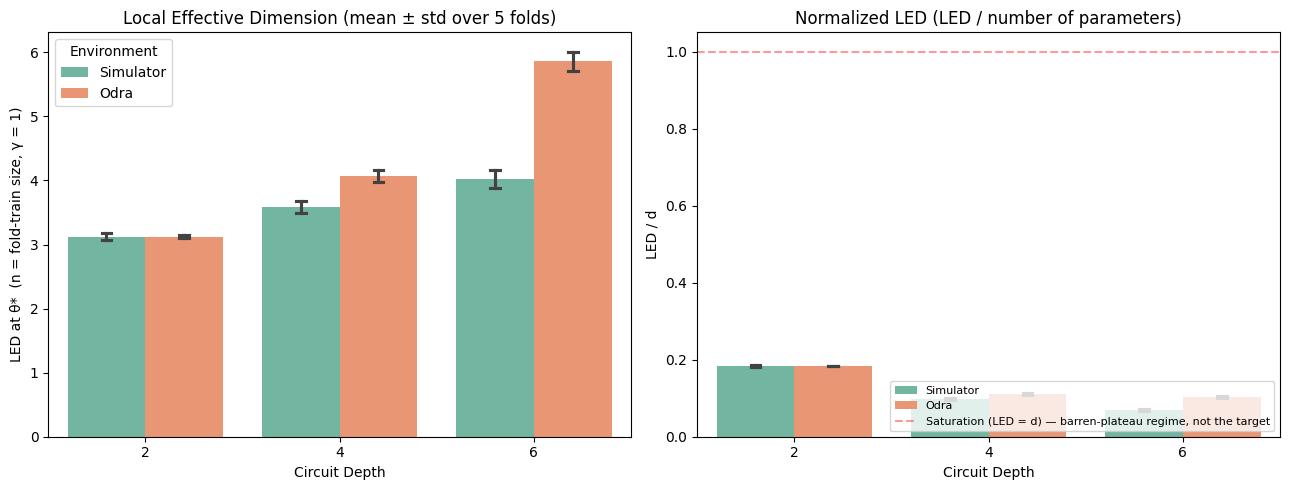


--- LOCAL EFFECTIVE DIMENSION (mean ± std across 5 folds, noise-free training) ---
Environment  Depth  LED_mean  LED_std  Norm_mean  Norm_std  Folds
       Odra      2     3.123    0.019      0.184     0.001      5
       Odra      4     4.075    0.094      0.110     0.003      5
       Odra      6     5.859    0.153      0.103     0.003      5
  Simulator      2     3.123    0.051      0.184     0.003      5
  Simulator      4     3.580    0.092      0.097     0.002      5
  Simulator      6     4.018    0.140      0.070     0.002      5


In [6]:
import seaborn as sns

RESULTS_CSV = "led_results.csv"
try:
    df_results
    if len(df_results) == 0:
        raise ValueError("empty in-memory results")
except (NameError, ValueError):
    df_results = pd.read_csv(RESULTS_CSV)
    print(f"Loaded {len(df_results)} rows from {RESULTS_CSV}")

df_clean = df_results[df_results["Noise"] == False].copy()

# Mean +/- std across the 5 folds for each (Environment, Depth) combination.
agg = (
    df_clean.groupby(["Environment", "Depth"])
    .agg(
        LED_mean=("LED", "mean"),
        LED_std=("LED", "std"),
        Norm_mean=("Normalized_LED", "mean"),
        Norm_std=("Normalized_LED", "std"),
        Folds=("LED", "count"),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(
    data=df_clean,
    x="Depth",
    y="LED",
    hue="Environment",
    errorbar="sd",
    capsize=0.1,
    palette="Set2",
    ax=axes[0],
)
axes[0].set_title("Local Effective Dimension (mean ± std over 5 folds)")
axes[0].set_ylabel("LED at θ*  (n = fold-train size, γ = 1)")
axes[0].set_xlabel("Circuit Depth")

# Normalized LED = LED / d. The y=1 line marks saturation (every parameter is a
# fully independent Fisher direction), which by Holmes et al. (2022) corresponds
# to the regime where gradients vanish (barren plateau). It is NOT the desirable
# target — the useful regime is a moderately high, fold-stable value still
# bounded by the training-set size n.
sns.barplot(
    data=df_clean,
    x="Depth",
    y="Normalized_LED",
    hue="Environment",
    errorbar="sd",
    capsize=0.1,
    palette="Set2",
    ax=axes[1],
)
axes[1].axhline(
    y=1.0,
    color="r",
    linestyle="--",
    alpha=0.4,
    label="Saturation (LED = d) — barren-plateau regime, not the target",
)
axes[1].set_title("Normalized LED (LED / number of parameters)")
axes[1].set_ylabel("LED / d")
axes[1].set_xlabel("Circuit Depth")
axes[1].legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()

print("\n--- LOCAL EFFECTIVE DIMENSION (mean ± std across 5 folds, noise-free training) ---")
print(agg.round(3).to_string(index=False))

## LED with and without noise

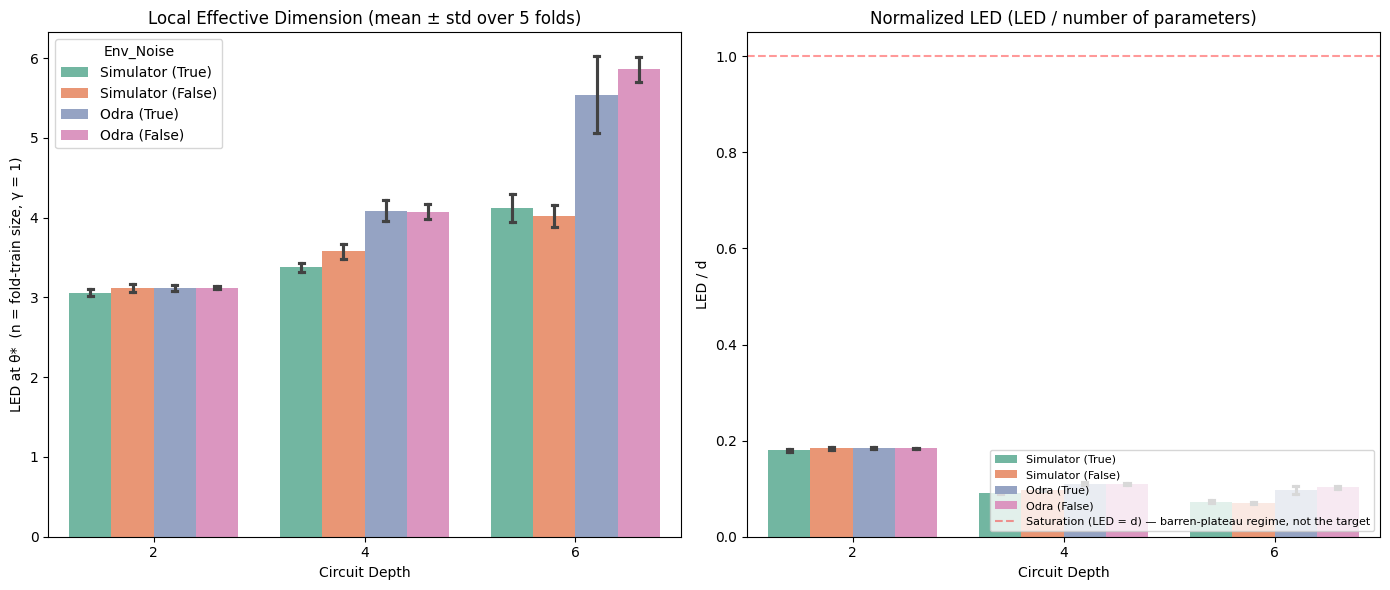


--- LOCAL EFFECTIVE DIMENSION (mean ± std across 5 folds) ---
Environment  Depth  Noise  LED_mean  LED_std  Norm_mean  Norm_std  Folds
       Odra      2  False     3.123    0.019      0.184     0.001      5
       Odra      2   True     3.124    0.037      0.184     0.002      5
       Odra      4  False     4.075    0.094      0.110     0.003      5
       Odra      4   True     4.090    0.133      0.111     0.004      5
       Odra      6  False     5.859    0.153      0.103     0.003      5
       Odra      6   True     5.541    0.482      0.097     0.008      5
  Simulator      2  False     3.123    0.051      0.184     0.003      5
  Simulator      2   True     3.061    0.047      0.180     0.003      5
  Simulator      4  False     3.580    0.092      0.097     0.002      5
  Simulator      4   True     3.376    0.057      0.091     0.002      5
  Simulator      6  False     4.018    0.140      0.070     0.002      5
  Simulator      6   True     4.126    0.177      0.072     0

In [ ]:
df_results["Env_Noise"] = df_results["Environment"] + " (" + df_results["Noise"].astype(str) + ")"

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(
    data=df_results,
    x="Depth",
    y="LED",
    hue="Env_Noise", 
    errorbar="sd",
    capsize=0.1,
    palette="Set2",
    ax=axes[0],
)
axes[0].set_title("Local Effective Dimension (mean ± std over 5 folds)")
axes[0].set_ylabel("LED at θ*  (n = fold-train size, γ = 1)")
axes[0].set_xlabel("Circuit Depth")

sns.barplot(
    data=df_results,
    x="Depth",
    y="Normalized_LED",
    hue="Env_Noise",
    errorbar="sd",
    capsize=0.1,
    palette="Set2",
    ax=axes[1],
)
axes[1].axhline(
    y=1.0,
    color="r",
    linestyle="--",
    alpha=0.4,
    label="Saturation (LED = d) — barren-plateau regime, not the target",
)
axes[1].set_title("Normalized LED (LED / number of parameters)")
axes[1].set_ylabel("LED / d")
axes[1].set_xlabel("Circuit Depth")
axes[1].legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()

print("\n--- LOCAL EFFECTIVE DIMENSION (mean ± std across 5 folds) ---")
print(agg.round(3).to_string(index=False))